In [129]:
## SUPERSTORE SALES AND PROFITABILITY ANALYSIS

## OBEJECTIVE
#To Analyze saleas trends,profitability drivers, impact of discount across category and regions.

## DATASET
# 7,594 ROWS
# 23 COLUMNS
# NO NULL VALUES

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Overview

In [131]:
df = pd.read_csv("C:/Users/kavya/Desktop/Data_Analyst_Journey/SQL Project/superstore_cleaned.csv")

In [132]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_Name,segment,country,city,state,...,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,order_year,order_month,delivery_days
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,3
1,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,7
2,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,7
3,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,Office Supplies,Art,Newell 322,7.28,4,0.00,1.97,2014,6,5
4,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.15,6,0.20,90.72,2014,6,5


In [133]:
df.shape

(7594, 23)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7594 entries, 0 to 7593
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       7594 non-null   object 
 1   order_date     7594 non-null   object 
 2   ship_date      7594 non-null   object 
 3   ship_mode      7594 non-null   object 
 4   customer_id    7594 non-null   object 
 5   customer_Name  7594 non-null   object 
 6   segment        7594 non-null   object 
 7   country        7594 non-null   object 
 8   city           7594 non-null   object 
 9   state          7594 non-null   object 
 10  postal_code    7594 non-null   int64  
 11  Region         7594 non-null   object 
 12  Product_ID     7594 non-null   object 
 13  Category       7594 non-null   object 
 14  Sub_Category   7594 non-null   object 
 15  Product_Name   7594 non-null   object 
 16  Sales          7594 non-null   float64
 17  Quantity       7594 non-null   int64  
 18  Discount

In [135]:
df.describe()

,postal_code,Sales,Quantity,Discount,Profit,order_year,order_month,delivery_days
count,7594.000000,7594.000000,7594.000000,7594.000000,7594.000000,7594.000000,7594.000000,7594.000000
mean,55492.093890,223.135586,3.789571,0.154571,28.946471,2015.712536,7.804714,3.941796
std,32000.599137,600.106266,2.218172,0.203948,245.614958,1.129065,3.274673,1.746788
min,1040.000000,0.560000,1.000000,0.000000,-6599.980000,2014.000000,1.000000,0.000000
25%,23498.500000,15.710000,2.000000,0.000000,1.710000,2015.000000,5.000000,3.000000
50%,59758.000000,49.820000,3.000000,0.200000,8.220000,2016.000000,9.000000,4.000000
75%,90008.000000,199.980000,5.000000,0.200000,28.785000,2017.000000,11.000000,5.000000
max,99301.000000,17499.950000,14.000000,0.800000,8399.980000,2017.000000,12.000000,7.000000


In [136]:
df.isnull().sum()

order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_Name    0
segment          0
country          0
city             0
state            0
postal_code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
order_year       0
order_month      0
delivery_days    0
dtype: int64

## Data Cleaning
- converted order_date & ship_date to datetime format
- extracted order_month_name
- verified no null values
- checked for duplicate records
- created profit margin column
These steps ensure clean and reloiable data for analysis

In [137]:
#converting dates - converting to datetime format
df["order_date"]=pd.to_datetime(df["order_date"])
df["ship_date"]=pd.to_datetime(df["ship_date"])

In [138]:
df.dtypes

order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_Name            object
segment                  object
country                  object
city                     object
state                    object
postal_code               int64
Region                   object
Product_ID               object
Category                 object
Sub_Category             object
Product_Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
order_year                int64
order_month               int64
delivery_days             int64
dtype: object

In [139]:
# Etracted order month name
df["order_month_name"]=df["order_date"].dt.month_name()

In [140]:
df.isnull().sum()

order_id            0
order_date          0
ship_date           0
ship_mode           0
customer_id         0
customer_Name       0
segment             0
country             0
city                0
state               0
postal_code         0
Region              0
Product_ID          0
Category            0
Sub_Category        0
Product_Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
order_year          0
order_month         0
delivery_days       0
order_month_name    0
dtype: int64

In [141]:
df.duplicated().sum()

np.int64(0)

In [142]:
df["ProfitMargin"]=round((df["Profit"]/df["Sales"])*100,2)

In [143]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_Name,segment,country,city,state,...,Product_Name,Sales,Quantity,Discount,Profit,order_year,order_month,delivery_days,order_month_name,ProfitMargin
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,3,November,16.00
1,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,7,October,-40.00
2,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,7,October,11.27
3,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,Newell 322,7.28,4,0.00,1.97,2014,6,5,June,27.06
4,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,Mitel 5320 IP Phone VoIP phone,907.15,6,0.20,90.72,2014,6,5,June,10.00


## Business KPIs
- Total Sales
- Total Profit
- Total Orders
- Overall Profit Margins
These helps us understand the overall business performance

In [144]:
total_sales=df["Sales"].sum()
total_profit=df["Profit"].sum()
Profit_Margin=total_profit/total_sales
total_orders=df["order_id"].nunique()

In [145]:
#KPI
print("Total_Sales:",round(total_sales,2))
print("Total_Profit:",round(total_profit,2))
print("Profit_Margin:",f"{Profit_Margin:.2%}")
print("Total_Orders:",total_orders)

Total_Sales: 1694491.64
Total_Profit: 219819.5
Profit_Margin: 12.97%
Total_Orders: 4322


## Time Trend Analysis
- Yearly Sales And Profits
- Monthly Sales And Profits
- Identification high and low Sales and Profits yearly or monthly
From this we can analyse seasonal patterns and growth Stratergy

In [146]:
# Total Sales , Profit and ProfitMargin by year
total_sales_yearly=df.groupby("order_year")[["Sales","Profit"]].sum()
Profit_Margin_yearly=total_sales_yearly["Profit"]/total_sales_yearly["Sales"]
total_sales_yearly["ProfitMargin"]= round(Profit_Margin_yearly*100,2)
total_sales_yearly

,Sales,Profit,ProfitMargin
order_year,,,
2014,352862.85,35968.78,10.19
2015,328374.28,44116.92,13.43
2016,454660.00,61360.35,13.50
2017,558594.51,78373.45,14.03


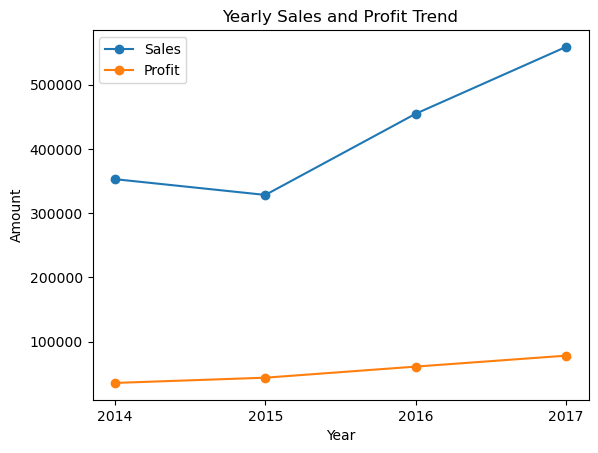

In [147]:
total_sales_yearly=total_sales_yearly.reset_index()
plt.plot(total_sales_yearly["order_year"],total_sales_yearly["Sales"],marker="o",label="Sales")
plt.plot(total_sales_yearly["order_year"],total_sales_yearly["Profit"],marker="o",label="Profit")
plt.title("Yearly Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.xticks(total_sales_yearly["order_year"])
plt.legend()
plt.show()

In [148]:
# Total Sales , Profit and ProfitMargin by year and month
monthly_sales=df.groupby(["order_month","order_month_name","order_year"])[["Sales","Profit"]].sum()
Profit_Margin_Monthly=monthly_sales["Profit"]/monthly_sales["Sales"]
monthly_sales["ProfitMargin"]= round(Profit_Margin_Monthly*100,2)
monthly_sales.sort_values(by="order_month")
monthly_sales

Sales    Profit  ProfitMargin
order_month order_month_name order_year                                  
1           January          2014        10857.21   1670.72         15.39
                             2015        11765.20   -571.81         -4.86
                             2016        11587.79   1568.96         13.54
                             2017        38420.79   6551.39         17.05
2           February         2014         3982.44    746.97         18.76
                             2015         5291.29    945.59         17.87
                             2016        11762.62   1997.03         16.98
                             2017        13096.87    551.19          4.21
3           March            2014        26410.26   1827.45          6.92
                             2015        21615.51   5083.60         23.52
                             2016        44528.71   3259.82          7.32
                             2017        51304.29  14043.26         27.37
4           April            2014        22876.70   2317.12         10.13
                             2015        23797.45   1514.14          6.36
                             2016        30717.13   2741.81          8.93
                             2017        30737.42    678.12          2.21
5           May              2014        20889.17   2545.23         12.18
                             2015        22189.88   3931.10         17.72
                             2016        46791.23   6987.94         14.93
                             2017        29796.73   4351.39         14.60
6           June             2014        24201.54   3860.73         15.95
                             2015        16327.18   2065.13         12.65
                             2016        29001.08   3705.18         12.78
                             2017        34778.39   5005.62         14.39
7           July             2014        28834.46  -1480.80         -5.14
                             2015        17213.36   1757.28         10.21
                             2016        27865.17   3509.41         12.59
                             2017        31449.22   5247.79         16.69
8           August           2014        24707.88   4921.92         19.92
                             2015        30540.58   5066.56         16.59
                             2016        23838.54   1526.23          6.40
                             2017        52665.72   7236.24         13.74
9           September        2014        65190.00   7598.96         11.66
                             2015        47259.91   8148.51         17.24
                             2016        55685.68   7796.12         14.00
                             2017        66973.42  10120.70         15.11
10          October          2014        24242.36   3011.22         12.42
                             2015        23930.25   1786.52          7.47
                             2016        46256.80  15138.30         32.73
                             2017        57160.78   6585.27         11.52
11          November         2014        56880.29   5301.73          9.32
                             2015        52129.21   8127.44         15.59
                             2016        59924.73   -316.41         -0.53
                             2017        92121.37  12248.51         13.30
12          December         2014        43790.54   3647.53          8.33
                             2015        56314.46   6262.86         11.12
                             2016        66700.52  13445.96         20.16
                             2017        60089.51   5753.97          9.58

In [149]:
monthly_sales=monthly_sales.reset_index()
monthly_sales["yearmonth"]=(monthly_sales["order_year"].astype(str)+"-"+monthly_sales["order_month"].astype(str).str.zfill(2))

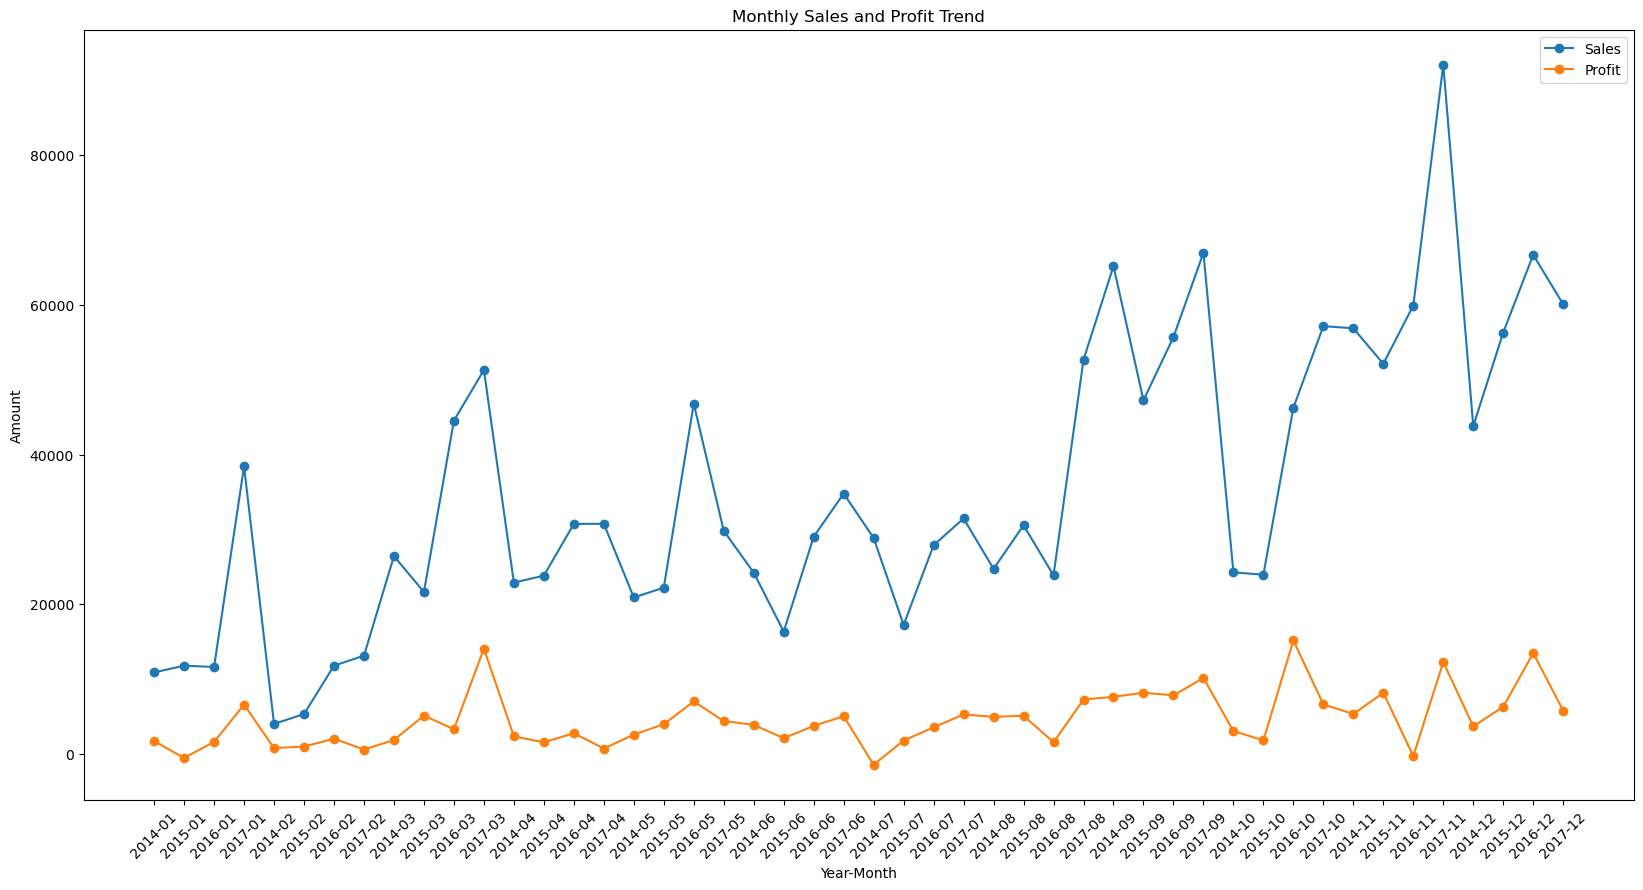

In [150]:
plt.figure(figsize=(20,10))
plt.plot(monthly_sales["yearmonth"],monthly_sales["Sales"],marker="o",label="Sales")
plt.plot(monthly_sales["yearmonth"],monthly_sales["Profit"],marker="o",label="Profit")
plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [151]:
# max sales and min profit
monthly_sales.loc[monthly_sales["Sales"].idxmax()]

order_month               11
order_month_name    November
order_year              2017
Sales               92121.37
Profit              12248.51
ProfitMargin            13.3
yearmonth            2017-11
Name: 43, dtype: object

In [152]:
monthly_sales.loc[monthly_sales["Profit"].idxmin()]

order_month                7
order_month_name        July
order_year              2014
Sales               28834.46
Profit               -1480.8
ProfitMargin           -5.14
yearmonth            2014-07
Name: 24, dtype: object

## Monthly Performance Classification

In [153]:
monthly_sales.agg({"Sales":"median","Profit":"median"})

Sales     30168.655
Profit     3782.955
dtype: float64

In [154]:
monthly_sales.agg({"Sales":"mean","Profit":"mean"})

Sales     35301.909167
Profit     4579.572917
dtype: float64

In [155]:
monthly_sales[monthly_sales["Sales"]>monthly_sales["Sales"].median()]

,order_month,order_month_name,order_year,Sales,Profit,ProfitMargin,yearmonth
3,1,January,2017,38420.79,6551.39,17.05,2017-01
10,3,March,2016,44528.71,3259.82,7.32,2016-03
11,3,March,2017,51304.29,14043.26,27.37,2017-03
14,4,April,2016,30717.13,2741.81,8.93,2016-04
15,4,April,2017,30737.42,678.12,2.21,2017-04
18,5,May,2016,46791.23,6987.94,14.93,2016-05
23,6,June,2017,34778.39,5005.62,14.39,2017-06
27,7,July,2017,31449.22,5247.79,16.69,2017-07
29,8,August,2015,30540.58,5066.56,16.59,2015-08
31,8,August,2017,52665.72,7236.24,13.74,2017-08


In [156]:

monthly_sales[(monthly_sales["Sales"]>monthly_sales["Sales"].median())&(monthly_sales["ProfitMargin"]<monthly_sales["ProfitMargin"].median())]

,order_month,order_month_name,order_year,Sales,Profit,ProfitMargin,yearmonth
10,3,March,2016,44528.71,3259.82,7.32,2016-03
14,4,April,2016,30717.13,2741.81,8.93,2016-04
15,4,April,2017,30737.42,678.12,2.21,2017-04
32,9,September,2014,65190.00,7598.96,11.66,2014-09
39,10,October,2017,57160.78,6585.27,11.52,2017-10
40,11,November,2014,56880.29,5301.73,9.32,2014-11
42,11,November,2016,59924.73,-316.41,-0.53,2016-11
44,12,December,2014,43790.54,3647.53,8.33,2014-12
45,12,December,2015,56314.46,6262.86,11.12,2015-12
47,12,December,2017,60089.51,5753.97,9.58,2017-12


## Category Performance
- category Level performance helps us to identify which categories drive revenue and which impacts profitability.

In [157]:
# Total Sales , Profit and ProfitMargin by year and category
total_sales_yearly_category=df.groupby(["order_year","Category"])[["Sales","Profit"]].sum()
Profit_Margin_yc=total_sales_yearly_category["Profit"]/total_sales_yearly_category["Sales"]
total_sales_yearly_category["ProfitMargin"]= round(Profit_Margin_yc*100,2)
total_sales_yearly_category

Sales    Profit  ProfitMargin
order_year Category                                          
2014       Furniture        111730.54   2914.07          2.61
           Office Supplies  122816.13  16848.38         13.72
           Technology       118316.18  16206.33         13.70
2015       Furniture        105889.02   5906.18          5.58
           Office Supplies   88999.89  11722.15         13.17
           Technology       133485.37  26488.59         19.84
2016       Furniture        124884.04   3549.73          2.84
           Office Supplies  141053.48  25690.88         18.21
           Technology       188722.48  32119.74         17.02
2017       Furniture        131052.59   3621.77          2.76
           Office Supplies  195905.44  32791.27         16.74
           Technology       231636.48  41960.41         18.11

In [158]:
total_sales_yearly_category=total_sales_yearly_category.reset_index()
Category_perf_pivot=total_sales_yearly_category.pivot(
    index="order_year",
    columns="Category",
    values="Profit"
)
Category_perf_pivot

Category,Furniture,Office Supplies,Technology
order_year,,,
2014,2914.07,16848.38,16206.33
2015,5906.18,11722.15,26488.59
2016,3549.73,25690.88,32119.74
2017,3621.77,32791.27,41960.41


<Figure size 800x500 with 0 Axes>

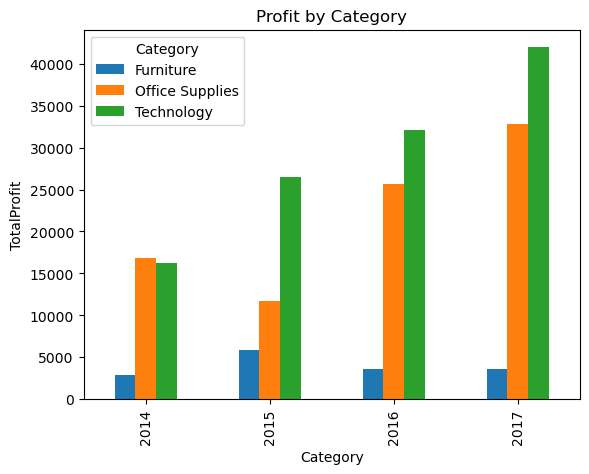

In [159]:
plt.figure(figsize=(8,5))
Category_perf_pivot.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("TotalProfit")
plt.legend(title="Category")
plt.show()


## Regional Performance
- Sales and Profits across regions.
- highlights geographical performance.

In [160]:
# Total Sales , Profit and ProfitMargin by year & Region
total_sales_Region=df.groupby(["order_year","Region"])[["Sales","Profit"]].sum()
Profit_Margin_Region=total_sales_Region["Profit"]/total_sales_Region["Sales"]
total_sales_Region["ProfitMargin"]= round(Profit_Margin_Region*100,2)
total_sales_Region

Sales    Profit  ProfitMargin
order_year Region                                    
2014       Central   79801.31  -1125.75         -1.41
           East      88273.92   8979.02         10.17
           South     64552.71  11836.80         18.34
           West     120234.91  16278.71         13.54
2015       Central   79991.40  10236.00         12.80
           East      99829.19  13473.44         13.50
           South     45502.79   4398.69          9.67
           West     103050.90  16008.79         15.53
2016       Central  109855.39  17887.05         16.28
           East     141252.44  15445.35         10.93
           South     58049.59   7801.73         13.44
           West     145502.58  20226.22         13.90
2017       Central  115964.16  11163.10          9.63
           East     156009.10  26490.80         16.98
           South     95317.34   7892.04          8.28
           West     191303.91  32827.51         17.16

In [161]:
total_sales_Region=total_sales_Region.reset_index()
Region_perf_pivot=total_sales_Region.pivot(
    index="order_year",
    columns="Region",
    values="Profit"
)
Region_perf_pivot


Region,Central,East,South,West
order_year,,,,
2014,-1125.75,8979.02,11836.80,16278.71
2015,10236.00,13473.44,4398.69,16008.79
2016,17887.05,15445.35,7801.73,20226.22
2017,11163.10,26490.80,7892.04,32827.51


<Figure size 800x500 with 0 Axes>

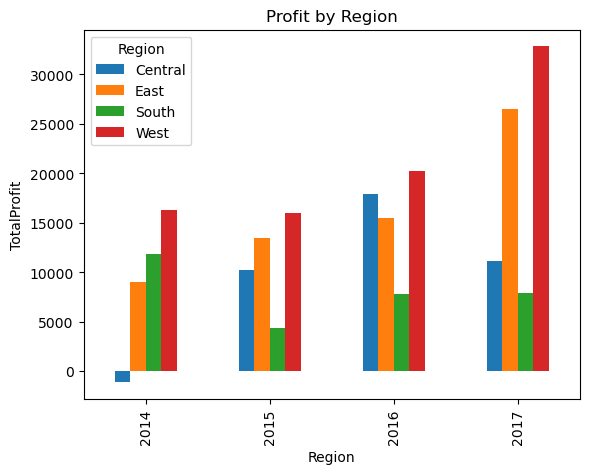

In [162]:
plt.figure(figsize=(8,5))
Region_perf_pivot.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("TotalProfit")
plt.legend(title="Region")
plt.show()


In [163]:
# Total Sales , Profit and ProfitMargin by Year, Category and Region
total_sales_RC=df.groupby(["order_year","Region","Category"])[["Sales","Profit"]].sum()
Profit_Margin_RC=total_sales_RC["Profit"]/total_sales_RC["Sales"]
total_sales_RC["ProfitMargin"]= round(Profit_Margin_RC*100,2)
total_sales_RC

Sales    Profit  ProfitMargin
order_year Region  Category                                         
2014       Central Furniture        23539.93  -1212.29         -5.15
                   Office Supplies  28698.65   -641.91         -2.24
                   Technology       27562.73    728.45          2.64
           East    Furniture        35810.76   -312.79         -0.87
                   Office Supplies  26062.73   4608.03         17.68
                   Technology       26400.43   4683.78         17.74
           South   Furniture        17747.47   2341.44         13.19
                   Office Supplies  23752.75   4885.58         20.57
                   Technology       23052.49   4609.78         20.00
           West    Furniture        34632.38   2097.71          6.06
                   Office Supplies  44302.00   7996.68         18.05
                   Technology       41300.53   6184.32         14.97
2015       Central Furniture        23973.90    670.77          2.80
                   Office Supplies  16223.82    -26.88         -0.17
                   Technology       39793.68   9592.11         24.10
           East    Furniture        26317.79   1128.87          4.29
                   Office Supplies  27748.50   6213.94         22.39
                   Technology       45762.90   6130.63         13.40
           South   Furniture        13065.23   1604.08         12.28
                   Office Supplies  19016.72   -986.05         -5.19
                   Technology       13420.84   3780.66         28.17
           West    Furniture        42532.10   2502.46          5.88
                   Office Supplies  26010.85   6521.14         25.07
                   Technology       34507.95   6985.19         20.24
2016       Central Furniture        28998.75    253.95          0.88
                   Office Supplies  37475.13   5291.56         14.12
                   Technology       43381.51  12341.54         28.45
           East    Furniture        26850.32    278.52          1.04
                   Office Supplies  47216.02   8422.73         17.84
                   Technology       67186.10   6744.10         10.04
           South   Furniture        18256.11   1164.47          6.38
                   Office Supplies  21181.32   3289.42         15.53
                   Technology       18612.16   3347.84         17.99
           West    Furniture        50778.86   1852.79          3.65
                   Office Supplies  35181.01   8687.17         24.69
                   Technology       59542.71   9686.26         16.27
2017       Central Furniture        28847.11    778.86          2.70
                   Office Supplies  48024.48   2621.11          5.46
                   Technology       39092.57   7763.13         19.86
           East    Furniture        33533.38   1052.56          3.14
                   Office Supplies  52301.53   8997.48         17.20
                   Technology       70174.19  16440.76         23.43
           South   Furniture        21610.81    535.59          2.48
                   Office Supplies  33610.99   4677.79         13.92
                   Technology       40095.54   2678.66          6.68
           West    Furniture        47061.29   1254.76          2.67
                   Office Supplies  61968.44  16494.89         26.62
                   Technology       82274.18  15077.86         18.33

## Discount Impact Analysis
- This shows how discounting impacts profits , Sales and Profit margins 

In [164]:
# discount impact analysis across year, region,category
Avg_Discount=df.groupby(["order_year","Region","Category"])[["Sales","Profit","Discount"]].agg({"Sales":"sum","Profit":"sum","Discount":"mean"})
Profit_Margin=Avg_Discount["Profit"]/Avg_Discount["Sales"]
Avg_Discount["Discount"]= round(Avg_Discount["Discount"]*100,2)
Avg_Discount["ProfitMargin"]= round(Profit_Margin*100,2)
Avg_Discount

Sales    Profit  Discount  ProfitMargin
order_year Region  Category                                                   
2014       Central Furniture        23539.93  -1212.29     33.66         -5.15
                   Office Supplies  28698.65   -641.91     26.17         -2.24
                   Technology       27562.73    728.45     16.35          2.64
           East    Furniture        35810.76   -312.79     16.37         -0.87
                   Office Supplies  26062.73   4608.03     16.23         17.68
                   Technology       26400.43   4683.78     16.49         17.74
           South   Furniture        17747.47   2341.44     10.90         13.19
                   Office Supplies  23752.75   4885.58     14.24         20.57
                   Technology       23052.49   4609.78      6.78         20.00
           West    Furniture        34632.38   2097.71     13.70          6.06
                   Office Supplies  44302.00   7996.68      7.92         18.05
                   Technology       41300.53   6184.32     14.11         14.97
2015       Central Furniture        23973.90    670.77     25.85          2.80
                   Office Supplies  16223.82    -26.88     25.97         -0.17
                   Technology       39793.68   9592.11     14.18         24.10
           East    Furniture        26317.79   1128.87     13.77          4.29
                   Office Supplies  27748.50   6213.94     13.53         22.39
                   Technology       45762.90   6130.63     13.89         13.40
           South   Furniture        13065.23   1604.08     10.58         12.28
                   Office Supplies  19016.72   -986.05     17.63         -5.19
                   Technology       13420.84   3780.66     11.75         28.17
           West    Furniture        42532.10   2502.46     12.69          5.88
                   Office Supplies  26010.85   6521.14      9.38         25.07
                   Technology       34507.95   6985.19     13.30         20.24
2016       Central Furniture        28998.75    253.95     29.05          0.88
                   Office Supplies  37475.13   5291.56     22.28         14.12
                   Technology       43381.51  12341.54     11.88         28.45
           East    Furniture        26850.32    278.52     15.43          1.04
                   Office Supplies  47216.02   8422.73     13.56         17.84
                   Technology       67186.10   6744.10     15.73         10.04
           South   Furniture        18256.11   1164.47     12.50          6.38
                   Office Supplies  21181.32   3289.42     18.19         15.53
                   Technology       18612.16   3347.84     13.21         17.99
           West    Furniture        50778.86   1852.79     14.51          3.65
                   Office Supplies  35181.01   8687.17     10.05         24.69
                   Technology       59542.71   9686.26     14.32         16.27
2017       Central Furniture        28847.11    778.86     28.71          2.70
                   Office Supplies  48024.48   2621.11     24.42          5.46
                   Technology       39092.57   7763.13     12.93         19.86
           East    Furniture        33533.38   1052.56     14.29          3.14
                   Office Supplies  52301.53   8997.48     14.65         17.20
                   Technology       70174.19  16440.76     13.45         23.43
           South   Furniture        21610.81    535.59     13.47          2.48
                   Office Supplies  33610.99   4677.79     16.92         13.92
                   Technology       40095.54   2678.66     12.68          6.68
           West    Furniture        47061.29   1254.76     13.51          2.67
                   Office Supplies  61968.44  16494.89      8.95         26.62
                   Technology       82274.18  15077.86     14.10         18.33

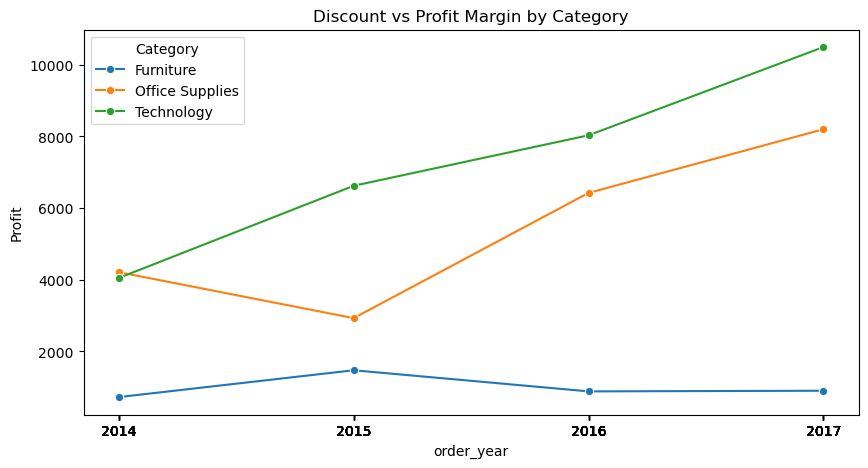

In [165]:
Avg_Discount=Avg_Discount.reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(
    data=Avg_Discount,
    x="order_year",
    y="Profit",
    hue="Category",
    marker="o",
    errorbar=None
)
plt.xticks(Avg_Discount["order_year"])
plt.title("Discount vs Profit Margin by Category")
plt.show()

## Root Cause Analysis
- Further Beakdown of the Category
  - Average discount for tables was significantly higher than other sub categories.
  - by which we can understand that high discounting is effecting profitability

In [166]:
sub_Avg_Discount=df.groupby(["Category","Sub_Category"])[["Sales","Profit","Discount"]].agg({"Sales":"sum","Profit":"sum","Discount":"mean"})
Profit_Margin_sub=sub_Avg_Discount["Profit"]/sub_Avg_Discount["Sales"]
sub_Avg_Discount["Discount"]= round(sub_Avg_Discount["Discount"]*100,2)
sub_Avg_Discount["ProfitMargin"]= round(Profit_Margin_sub*100,2)
sub_Avg_Discount

Sales    Profit  Discount  ProfitMargin
Category        Sub_Category                                             
Furniture       Bookcases      50193.63  -2452.44     20.09         -4.89
                Chairs        244117.67  20339.47     16.98          8.33
                Furnishings    45272.70   6940.82     13.84         15.33
                Tables        133972.19  -8836.10     25.79         -6.60
Office Supplies Appliances     56817.27   7009.40     16.48         12.34
                Art            19022.75   4694.66      7.47         24.68
                Binders       164826.40  20936.89     37.62         12.70
                Envelopes      12662.34   5376.50      7.65         42.46
                Fasteners       2646.42    792.42      8.34         29.94
                Labels          7134.53   3165.45      6.75         44.37
                Paper          66722.51  28968.56      7.59         43.42
                Storage       173657.45  17599.32      7.67         10.13
                Supplies       45285.27  -1490.52      7.66         -3.29
Technology      Accessories   109186.17  26125.45      7.91         23.93
                Copiers       144668.18  54462.93     16.39         37.65
                Machines      119654.16  -3651.52     32.41         -3.05
                Phones        298652.00  39838.21     15.64         13.34

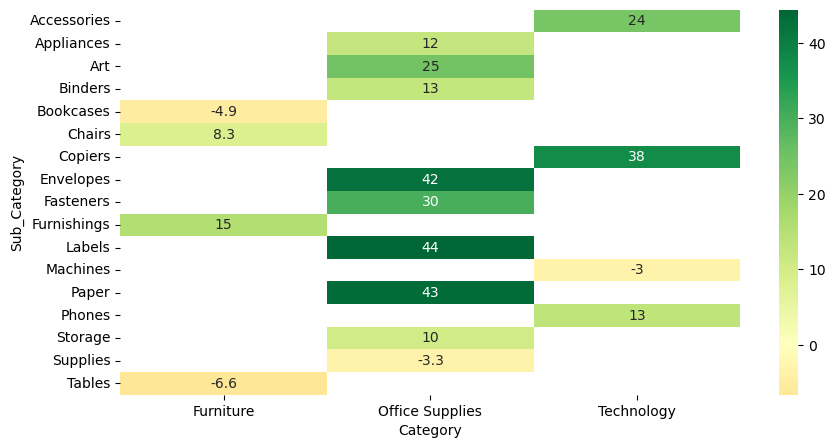

In [167]:
sub_Avg_Discount=sub_Avg_Discount.reset_index()
heat_data=sub_Avg_Discount.pivot(
    index="Sub_Category",
    columns="Category",
    values="ProfitMargin"
)
plt.figure(figsize=(10,5))
sns.heatmap(
    heat_data,
    annot=True,
    cmap="RdYlGn",
    center=0
)
plt.show()

## Correlaton Validation
- correlation analysis helps to find the relationship between key variables.

In [168]:
Avg_Discount.select_dtypes(include="number").corr()

,order_year,Sales,Profit,Discount,ProfitMargin
order_year,1.000000,0.453809,0.306597,-0.010356,0.062971
Sales,0.453809,1.000000,0.708980,-0.171963,0.244556
Profit,0.306597,0.708980,1.000000,-0.466376,0.803365
Discount,-0.010356,-0.171963,-0.466376,1.000000,-0.607872
ProfitMargin,0.062971,0.244556,0.803365,-0.607872,1.000000


In [169]:
# correlation between discount and profit margin yearly
Avg_Discount["Discount"].corr(Avg_Discount["ProfitMargin"])

np.float64(-0.6078723913744399)

In [170]:
# correlation of profit and sales monthly
monthly_sales.select_dtypes(include="number").corr()

,order_month,order_year,Sales,Profit,ProfitMargin
order_month,1.000000e+00,5.782903e-14,0.702459,0.444240,0.009922
order_year,5.782903e-14,1.000000e+00,0.361110,0.357463,0.108056
Sales,7.024589e-01,3.611097e-01,1.000000,0.721780,0.087513
Profit,4.442398e-01,3.574631e-01,0.721780,1.000000,0.681874
ProfitMargin,9.921655e-03,1.080557e-01,0.087513,0.681874,1.000000


In [171]:
# correlation of profit and sales monthly-sub category yearly
sub_Avg_Discount.select_dtypes(include="number").corr()

,Sales,Profit,Discount,ProfitMargin
Sales,1.000000,0.565546,0.398177,-0.336717
Profit,0.565546,1.000000,-0.076238,0.417562
Discount,0.398177,-0.076238,1.000000,-0.543074
ProfitMargin,-0.336717,0.417562,-0.543074,1.000000


In [172]:
sub_Avg_Discount["Discount"].corr(sub_Avg_Discount["ProfitMargin"])

np.float64(-0.5430743763892262)

## Key Business Insights
	•	Sales have grown steadily from 2014 to 2017.
	•	Profit growth is slower than revenue growth due to discount-heavy sales.
	•	Furniture category underperforms due to negative margins in Tables and Bookcases.
	•	Discount and Profit Margin show a strong negative correlation.
	•	Office Supplies and Technology maintain strong margin stability.

## Business Insights 
	•	Reduce discount intensity in Tables and Bookcases.
	•	Implement controlled discount thresholds to protect margins.
	•	Focus growth strategy on high-margin segments like Technology.
	•	Investigate regional loss patterns before aggressive promotions.
	•	Monitor discount-to-margin ratio quarterly.

In [ ]:
# To Export your cleaned Dataframe to a csv file
df.to_csv("Superstore_Cleaned.csv",index=False)